# Step 1: Preprocessing

• Resize images or video frames to a fixed size (e.g., 512x512).

• Convert images from BGR to HSV color space

• Apply color filtering to isolate red or blue regions (common traffic sign colors).

• Perform morphological operations (e.g., opening, closing) to reduce noise.

• You may perform additional preprocessing.


# Color-Based Traffic Sign Segmentation (Red & Blue Detection)

• Loads, resizes, and converts the input image to HSV for better color segmentation

• Detects red and blue regions using HSV masks, refines them with morphological operations, and visualizes the filtered result

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# === Load & Resize Image ===
img_path = r"C:\Users\User\image_final\TrainIJCNN2013\TrainIJCNN2013\00050.ppm" # 🔁 Replace with your actual image path
img = cv2.imread(img_path)
img = cv2.resize(img, (512, 512))

# === Convert to HSV ===
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# === Define Color Ranges ===
# Red (2 parts)
lower_red1 = np.array([0, 100, 100])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([160, 100, 100])
upper_red2 = np.array([179, 255, 255])

# Blue
lower_blue = np.array([100, 150, 50])
upper_blue = np.array([140, 255, 255])

# === Create Color Masks ===
red_mask = cv2.inRange(hsv, lower_red1, upper_red1) | cv2.inRange(hsv, lower_red2, upper_red2)
blue_mask = cv2.inRange(hsv, lower_blue, upper_blue)
combined_mask = cv2.bitwise_or(red_mask, blue_mask)

# === Morphological Operations ===
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
opened = cv2.morphologyEx(combined_mask, cv2.MORPH_OPEN, kernel)
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

# === Apply Final Mask ===
result = cv2.bitwise_and(img, img, mask=closed)

# === Display Results ===
plt.figure(figsize=(16, 6))

plt.subplot(1, 4, 1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title("Red + Blue Mask")
plt.imshow(combined_mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title("After Morphology")
plt.imshow(closed, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title("Filtered Image")
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()


# Load and Display Original Image

• Reads the input image from the specified path and resizes it to 512×512 pixels

• Displays the original image using Matplotlib with proper RGB color conversion

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

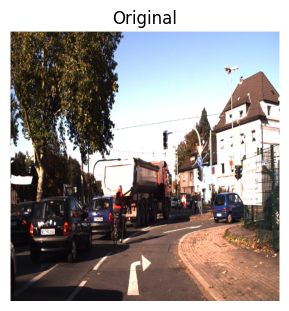

In [ ]:
img_path = r"C:\Users\User\Desktop\image_final\TrainIJCNN2013\TrainIJCNN2013\00050.ppm"# 🔁 Replace with your actual image path
img = cv2.imread(img_path)
img = cv2.resize(img, (512, 512))
plt.figure(figsize=(16, 6))

plt.subplot(1, 4, 1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

# Image Preprocessing Function for Color-Based Sign Detection

• Defines a reusable function to load, resize, and extract red/blue regions from traffic sign images using HSV color masks

• Applies morphological operations to clean the binary mask and returns both the cleaned mask and resized image

In [ ]:
import cv2
import numpy as np

img_path = r"C:\Users\User\Desktop\image_final\TrainIJCNN2013\TrainIJCNN2013\00050.ppm"

def preprocess_image(img_input, resize_shape=(512, 512)):
    """
    Preprocess an image for traffic sign detection.
    
    Parameters:
        img_input: str or np.array - path to image or loaded image array
        resize_shape: tuple - target size for resizing (default: 512x512)

    Returns:
        cleaned_mask: np.array - binary mask after color filtering and morphology
        resized_img: np.array - original image resized to target shape
    """

    # Load image if path is given
    if isinstance(img_input, str):
        img = cv2.imread(img_input)
    else:
        img = img_input.copy()

    if img is None:
        raise ValueError("Image not found or could not be loaded.")

    # Resize image
    resized_img = cv2.resize(img, resize_shape)

    # Convert to HSV
    hsv = cv2.cvtColor(resized_img, cv2.COLOR_BGR2HSV)

    # Red and Blue color masks
    lower_red1 = np.array([0, 100, 100])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([160, 100, 100])
    upper_red2 = np.array([179, 255, 255])
    lower_blue = np.array([100, 150, 50])
    upper_blue = np.array([140, 255, 255])

    red_mask = cv2.inRange(hsv, lower_red1, upper_red1) | cv2.inRange(hsv, lower_red2, upper_red2)
    blue_mask = cv2.inRange(hsv, lower_blue, upper_blue)
    combined_mask = cv2.bitwise_or(red_mask, blue_mask)

    # Morphological cleaning
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    opened = cv2.morphologyEx(combined_mask, cv2.MORPH_OPEN, kernel)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

    return closed, resized_img


# Apply Preprocessing and Visualize Mask

• Calls the preprocess_image function to generate a cleaned binary mask and resized image

• Displays the resulting mask highlighting detected red and blue regions in grayscale

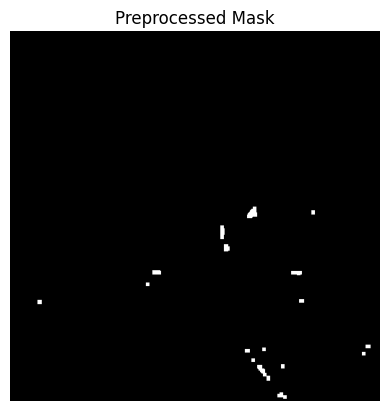

In [ ]:
mask, resized = preprocess_image(r"C:\Users\User\Desktop\image_final\TrainIJCNN2013\TrainIJCNN2013\00050.ppm")

# Optional: show result
import matplotlib.pyplot as plt
plt.imshow(mask, cmap='gray')
plt.title("Preprocessed Mask")
plt.axis('off')
plt.show()


# Step 2: Traffic Sign Detection (Using GTSDB)

• Use color segmentation and shape detection methods (such as contours and Hough Transform) to
locate traffic signs.

• Extract bounding boxes as Regions of Interest (ROIs).

# Contour Detection and Region Highlighting

• Detects external contours from the preprocessed mask and filters small regions by area threshold

• Draws bounding boxes around detected regions of interest (ROIs) on the original image for visualization

In [5]:
# Assuming `mask` is the result of your HSV + filtering
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > 100:  # filter out noise
        x, y, w, h = cv2.boundingRect(cnt)
        roi = img[y:y+h, x:x+w]
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)


# Traffic Sign Color Filtering and Contour-Based Detection

• filter_traffic_sign_colors: Extracts red and blue regions from the image using HSV thresholds to isolate common traffic sign colors

• detect_signs_with_contours: Finds contours in the mask, applies filters (area, aspect ratio, size), and returns bounding boxes and ROIs for likely traffic signs

In [23]:
def filter_traffic_sign_colors(img):
    """Convert image to HSV and create a mask for red & blue colors (common for traffic signs)."""
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Red mask (2 ranges)
    lower_red1 = np.array([0, 70, 50])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([170, 70, 50])
    upper_red2 = np.array([180, 255, 255])
    red_mask = cv2.inRange(hsv, lower_red1, upper_red1) | cv2.inRange(hsv, lower_red2, upper_red2)

    # Blue mask
    lower_blue = np.array([100, 100, 100])
    upper_blue = np.array([140, 255, 255])
    blue_mask = cv2.inRange(hsv, lower_blue, upper_blue)

    combined_mask = red_mask | blue_mask
    return combined_mask

def detect_signs_with_contours(img, mask, minarea=300):
    """Detect rectangular traffic signs using contours and extract ROIs and bounding boxes."""
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxed_img = img.copy()
    rois = []
    bounding_boxes = []

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 800 or area > 5000:
            continue
    
        x, y, w, h = cv2.boundingRect(cnt)
    
        # Aspect ratio filter
        aspect_ratio = w / h
        if aspect_ratio < 0.8 or aspect_ratio > 1.2:
            continue
    
        # Size filter
        if w < 20 or h < 20:
            continue
    
        # Draw and save
        cv2.rectangle(boxed_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
        roi = img[y:y + h, x:x + w]
        rois.append(roi)
        bounding_boxes.append((x, y, w, h))



    return boxed_img, rois, bounding_boxes


# Load and Preprocess GTSRB Training Dataset

• Iterates through all traffic sign class folders in the GTSRB dataset, resizing images to 32×32 and collecting them with labels

• Uses a progress bar for monitoring and converts the data into NumPy arrays for model training

In [ ]:
# 1. Load and Preprocess GTSRB Training Data with Progress Bar
import os
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split

gtsrb_path = r"C:\Users\User\Desktop\image_final\GTSRB_Final_Training_Images\GTSRB\Final_Training\Images"
X, y = [], []

# Loop through all class folders with progress bar
for class_id in tqdm(os.listdir(gtsrb_path), desc="Loading Classes"):
    class_dir = os.path.join(gtsrb_path, class_id)
    if os.path.isdir(class_dir):
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, (32, 32))
                X.append(img)
                y.append(int(class_id))

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

print("✅ Finished loading. Total images loaded:", len(X))


Loading Classes: 100%|██████████| 43/43 [06:29<00:00,  9.07s/it]

✅ Finished loading. Total images loaded: 39209


# Step 3: Classification (Using GTSRB)

• Resize ROIs to a fixed size (e.g., 32x32).

• Extract features (e.g., Histogram of Oriented Gradients (HOG) or any other technique).

• Train a classifier (e.g., Support Vector Machine - SVM) on the GTSRB training images.

• Predict the class of each detected ROI using the trained classifier.

# Feature Extraction Using HOG Descriptors

• Converts each image to grayscale and extracts Histogram of Oriented Gradients (HOG) features to capture edge and shape information

• Returns a feature matrix suitable for training traditional machine learning classifiers

In [11]:
#2. Feature Extraction using HOG (or use raw pixels)
from skimage.feature import hog

def extract_hog_features(images):
    features = []
    for img in images:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        hog_feat = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                       cells_per_block=(2, 2), block_norm='L2-Hys')
        features.append(hog_feat)
    return np.array(features)

X_hog = extract_hog_features(X)


# Train and Evaluate SVM Classifier on HOG Features

• Splits the HOG feature dataset into training and testing sets, then trains a linear Support Vector Machine (SVM)

• Predicts traffic sign classes on the test set and evaluates performance using accuracy score

In [12]:
#3. Train Classifier (SVM Recommended)
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X_hog, y, test_size=0.2, random_state=42)

svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
print("Accuracy on test set:", accuracy_score(y_test, y_pred))


Accuracy on test set: 0.9092068349910737


# Classify Detected ROIs Using Trained SVM

• Resizes each detected Region of Interest (ROI) to 32×32, extracts HOG features, and feeds them into the trained SVM classifier

• Returns the predicted class label for each traffic sign ROI

In [13]:
#4. Apply Classifier to Detected ROIs
#After Step 2, you should have extracted traffic sign ROIs from full images. Resize each ROI to 32x32 and extract HOG features:
def classify_roi(roi):
    roi_resized = cv2.resize(roi, (32, 32))
    gray = cv2.cvtColor(roi_resized, cv2.COLOR_BGR2GRAY)
    hog_feat = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), block_norm='L2-Hys')
    prediction = svm.predict([hog_feat])
    return prediction[0]


# Step 4: Annotation & Visualization

• Draw bounding boxes around detected signs on the image or video frames.

• Overlay predicted class labels along with confidence scores.

• Display or save the annotated images or video.

# Annotate and Visualize Classified Traffic Signs

• Uses the trained classifier to predict labels for detected ROIs, then draws bounding boxes and class names on the original image

• Displays the final annotated image with traffic signs visually identified and labeled for easy interpretation

In [26]:
import cv2
from skimage.feature import hog
import matplotlib.pyplot as plt

# ✅ Map of class_id to readable names (put actual class names here)
class_names = {
    0: "Speed Limit 20", 1: "Speed Limit", 14: "Stop", 17: "No Entry", 38: "Keep Right"
    # Add more as needed
}

# ✅ This function draws boxes and labels on the original image
def annotate_and_visualize(image, bounding_boxes, roi_images, classifier):
    annotated_image = image.copy()

    for bbox, roi in zip(bounding_boxes, roi_images):
        x, y, w, h = bbox

        # Step 1: Resize ROI to 32x32 and convert to gray
        roi_resized = cv2.resize(roi, (32, 32))
        gray = cv2.cvtColor(roi_resized, cv2.COLOR_BGR2GRAY)

        # Step 2: Extract HOG features
        features = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                       cells_per_block=(2, 2), block_norm='L2-Hys')

        # Step 3: Predict class
        class_id = classifier.predict([features])[0]
        label = class_names.get(class_id, str(class_id))  # fallback to ID if not in dict

        # Step 4: Draw bounding box and label
        cv2.rectangle(annotated_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(annotated_image, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, (0, 255, 0), 2)

    # Step 5: Show the annotated image
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Detected and Classified Traffic Signs")
    plt.show()


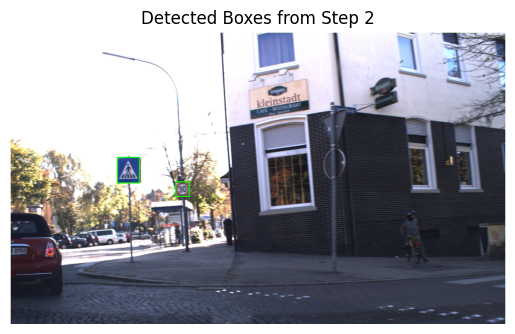

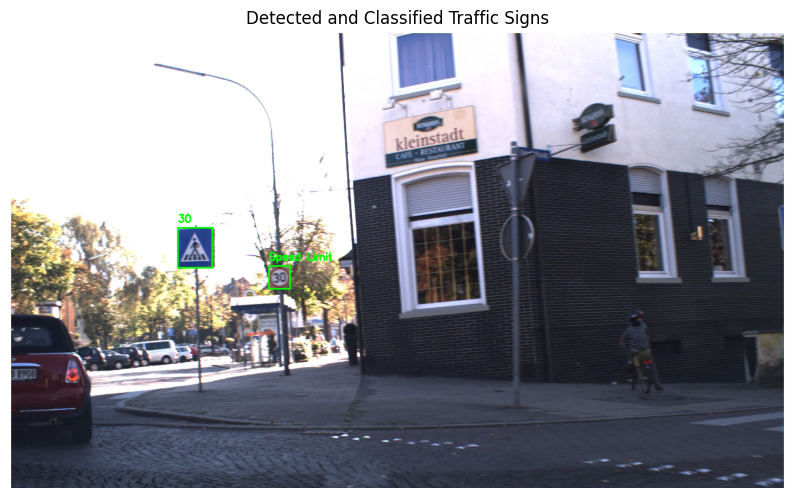

In [ ]:
# Load image
image_path = r"C:\Users\User\Desktop\image_final\TrainIJCNN2013\TrainIJCNN2013\00026.ppm"
image = cv2.imread(image_path)

# Step 1: Filter for red and blue colors
mask = filter_traffic_sign_colors(image)

# Step 2: Detect using contours
detected_img, roi_images, bounding_boxes = detect_signs_with_contours(image, mask, minarea=300)

# (Optional) Visualize detection result
plt.imshow(cv2.cvtColor(detected_img, cv2.COLOR_BGR2RGB))
plt.title("Detected Boxes from Step 2")
plt.axis('off')
plt.show()

# Step 3: Go to annotation
annotate_and_visualize(image, bounding_boxes, roi_images, svm)


# Step 5: Evaluation

• Evaluate Detection Performance by measuring accuracy of locating traffic signs:

• Use metrics such as Intersection over Union (IoU) between predicted and ground truth
bounding boxes.

• Evaluate Classification Performance by measuring accuracy, precision, recall, and F1-score on
predicted classes vs. ground truth.

• Analyze the overall pipeline by combining detection and classification results.

• Measure processing speed to assess real-time performance feasibility.

# Evaluate SVM Classifier Performance

• Computes and prints classification accuracy, a detailed classification report (precision, recall, F1-score), and a confusion matrix

• Visualizes the confusion matrix using a heatmap to assess how well the model distinguishes between different traffic sign classes

✅ Classification Accuracy: 0.9092068349910737

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.87      0.90        38
           1       0.79      0.78      0.78       496
           2       0.73      0.79      0.76       450
           3       0.89      0.88      0.89       280
           4       0.94      0.95      0.95       418
           5       0.71      0.70      0.71       364
           6       1.00      1.00      1.00        59
           7       0.86      0.89      0.88       278
           8       0.85      0.78      0.81       301
           9       0.90      0.95      0.93       268
          10       0.98      0.95      0.97       370
          11       0.80      0.87      0.84       236
          12       0.99      1.00      0.99       450
          13       1.00      1.00      1.00       452
          14       0.98      0.94      0.96       162
          15       0.98      0.99      0.99       120
         

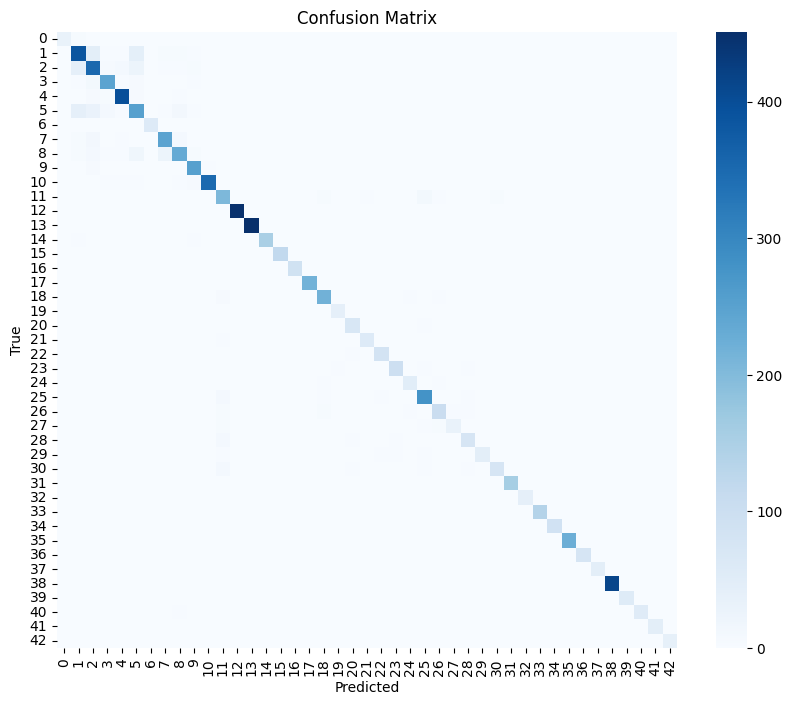

In [35]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on X_test
y_pred = svm.predict(X_test)

# Accuracy
print("✅ Classification Accuracy:", accuracy_score(y_test, y_pred))

# Detailed report
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y), annot=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


# Measure Inference Time for Detection and Classification

• Executes the full traffic sign detection and classification pipeline on a single image

• Measures and prints the total processing time to evaluate the system’s real-time performance potential

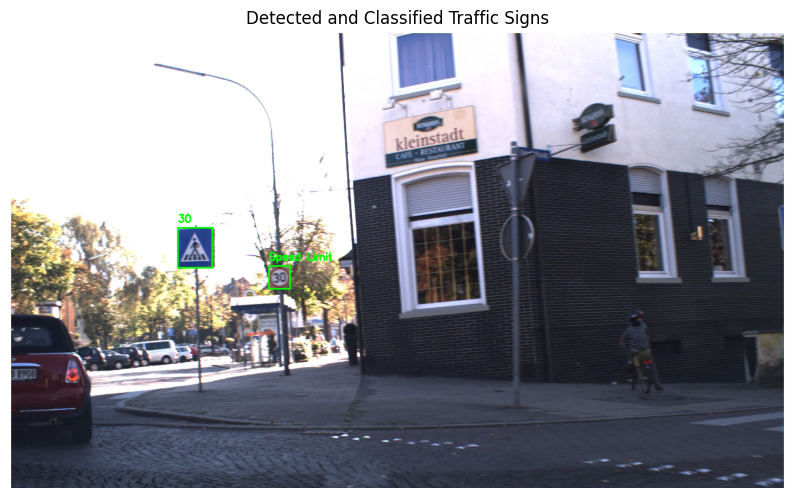

🕒 Processing Time: 0.47 seconds


In [36]:
import time

start = time.time()

# Run full detection and classification
mask = filter_traffic_sign_colors(image)
_, roi_images, bounding_boxes = detect_signs_with_contours(image, mask)
annotate_and_visualize(image, bounding_boxes, roi_images, svm)

end = time.time()
print(f"🕒 Processing Time: {end - start:.2f} seconds")
